# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}

In [8]:
data =  AS209

In [9]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

### CGM

In [10]:
    def get_atol_rtol(name, b_norm, atol=0., rtol=1e-5):
        """
        Scipy's helper function to handle tolerance normalization.
        See in https://github.com/scipy/scipy/blob/v1.16.2/scipy/sparse/linalg/_isolve/iterative.py#L158-L304.
        
        Parameters
        ----------
        name : str
            Name of the solver method.
        b_norm : float
            Norm of the right-hand side vector b.
        atol : float, optional
            Absolute tolerance. Default is 0.
        rtol : float, optional
            Relative tolerance. Default is 1e-5.
        """
        if atol == 'legacy' or atol is None or atol < 0:
            msg = (f"'scipy.sparse.linalg.{name}' called with invalid `atol`={atol}; "
                "if set, `atol` must be a real, non-negative number.")
            raise ValueError(msg)

        print(f'         * rtol: {float(rtol)}')

        atol = max(float(atol), float(rtol) * float(b_norm))
        print(f'         * final tolerance: {atol}')

        return atol, rtol

In [11]:
def plot_tolerance(tols, title = 'tols'):
    iterations = range(len(tols))
    tols = np.array(tols)

    plt.figure(figsize = (7,2))
    plt.plot(iterations, np.log(tols))
    plt.xlabel('iterations')
    plt.ylabel('log ' + title)
    plt.show()

In [12]:
def bicgstab_solver( A, b, x0=None, *, rtol=1e-7, atol=0., maxiter=None, M=None, callback=None):

    tols = []            # norma del residuo ||r||
    true_residuals = []  # residuo verdadero ||b - A@x||
    rhos = []            # valor escalar rho (producto interno r̃·r)
    omegas = []          # valor escalar omega
    alphas = []          # valor escalar alpha
    betas = []           # valor escalar beta

    def plot_all():
        plot_tolerance(tols, title = 'tols')


    A, M, x, b = make_system(A, M, x0, b)
    bnrm2 = np.linalg.norm(b)

    atol, _ = get_atol_rtol('bicgstab', bnrm2, atol, rtol)

    print("Final tolerance : ", atol)

    if bnrm2 == 0:
        return b, 0

    n = len(b)

    dotprod = np.vdot if np.iscomplexobj(x) else np.dot

    matvec = A.matvec
    psolve = M.matvec

    # These values make no sense but coming from original Fortran code
    # sqrt might have been meant instead.
    rhotol = np.finfo(x.dtype.char).eps**2
    omegatol = rhotol

    # Dummy values to initialize vars, silence linter warnings
    rho_prev, omega, alpha, p, v = None, None, None, None, None

    r = b - matvec(x) if x.any() else b.copy()
    rtilde = r.copy()

    tols = []

    for iteration in range(maxiter):
        print(".... iteration: ", iteration)
        act_tol = np.linalg.norm(r)
        tols.append(act_tol)
        print("                        -> actual tol: ", str(act_tol), "vs ", str(atol))
        if act_tol < atol:  # Are we done?
            print(" --------------------------------------> CGM converged in ", iteration, " iterations with tol ", act_tol)
            plot_all()
            return x, 0

        rho = dotprod(rtilde, r)
        if np.abs(rho) < rhotol:  # rho breakdown
            print("converged by norm of rho")
            plot_all()
            return x, -10

        beta = 0
        if iteration > 0:
            if np.abs(omega) < omegatol:  # omega breakdown
                print("converged by norm of omega")
                return x, -11

            beta = (rho / rho_prev) * (alpha / omega)
            p -= omega*v
            p *= beta
            p += r
        else:  # First spin
            s = np.empty_like(r)
            p = r.copy()

        phat = psolve(p)
        v = matvec(phat)
        rv = dotprod(rtilde, v)
        if rv == 0:
            print("converged by rv = 0")
            plot_all()
            return x, -11
        alpha = rho / rv
        r -= alpha*v
        s[:] = r[:]

        if np.linalg.norm(s) < atol:
            print("converged by norm of s")
            plot_all()
            x += alpha*phat
            return x, 0

        shat = psolve(s)
        t = matvec(shat)
        omega = dotprod(t, s) / dotprod(t, t)
        x += alpha*phat
        x += omega*shat
        r -= omega*t
        rho_prev = rho

        if callback:
            callback(x)

        true_residuals.append(np.linalg.norm(b - matvec(x)))
        rhos.append(np.abs(rho))
        omegas.append(np.abs(omega))
        alphas.append(np.abs(alpha))
        betas.append(np.abs(beta))

    else:  # for loop exhausted
        # Return incomplete progress
        plot_all()
        return x, maxiter

# Disk

In [10]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [11]:
params = {'m': -2, 'c': 1e8, 'l': 7e4}
#params = best_AS209

In [12]:
frank2d.set_kernel(type_kernel = 'Wendland', kernel_params = params)
frank2d.set_guess(None)

Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 70000.0}


In [13]:
frank2d.set_fit_method(rtol = 1e-8)


Creating sparse linear system...


--> time kernel = 0.03  min |  1.63 seconds
Using preconditioner method:  jacobi
--> time building system = 0.03  min |  1.69 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 2.881751982790494
Final tolerance :  2.881751982790494
.... iteration:  0
                        -> actual tol:  288175198.2790494 vs  2.881751982790494
.... iteration:  1
                        -> actual tol:  39773051.282940604 vs  2.881751982790494
.... iteration:  2
                        -> actual tol:  30605898.285020348 vs  2.881751982790494
.... iteration:  3
                        -> actual tol:  31458951.244856782 vs  2.881751982790494
.... iteration:  4
                        -> actual tol:  32660086.13231327 vs  2.881751982790494
.... iteration:  5
                        -> actual tol:  32037725.28316018 vs  2.881751982790494
.... iteration:  6
                        -> actual tol:  68809638.65897655 vs  2

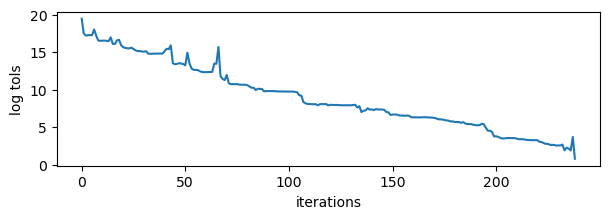

--> time = 0.13  min |  7.70 seconds
               ---> CGM converged?   True
                    x Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.05  min |  3.15 seconds


In [14]:
frank2d.fit()

In [15]:
Plot_ = Plot(frank2d)

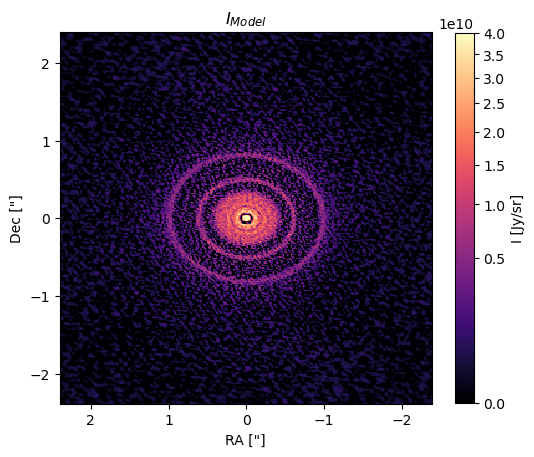

In [16]:
Plot_.intensity()

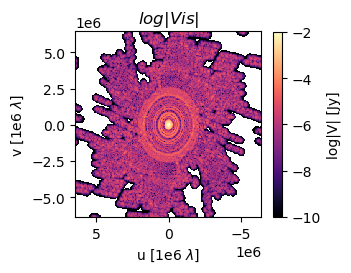

In [18]:
Plot_.visibility()